## SVM

SVM is the most common (we can say after neural network) classifier. First we talk about a concept called **margin**, and then we talk about that SVM is looking for **maximizing the margin**, and we talk about it's optimization, and then we remove our assumption of data being able to linearly classified and talk about **Soft-Margin SVM** and then we get to non-linear SVM and **kernel methods**.

### Margin

In a linearly separable problem and data samples we normally can devide two classes with bunch of hyperplane and all of them would classify our samples very well but have different equations. Now the question is that which one of those hyperplane we would prefer to be the decision boundary of our problem?<br>
Technically the one hyperplane is better than the others that have the maximum distance from data samples which it is deviding them, and this specific hyper plane would also lead to a better generalization than the other possible hyperplanes. So:

**Margin** for a hyperplane that separates samples of two linearly separable classes is the **smallest** distance between the decision boundary and any of the training samples. 

Now we know that **margin** is a value that is definable for each hyperplane.<br>

For a better understanding look at the figure below:

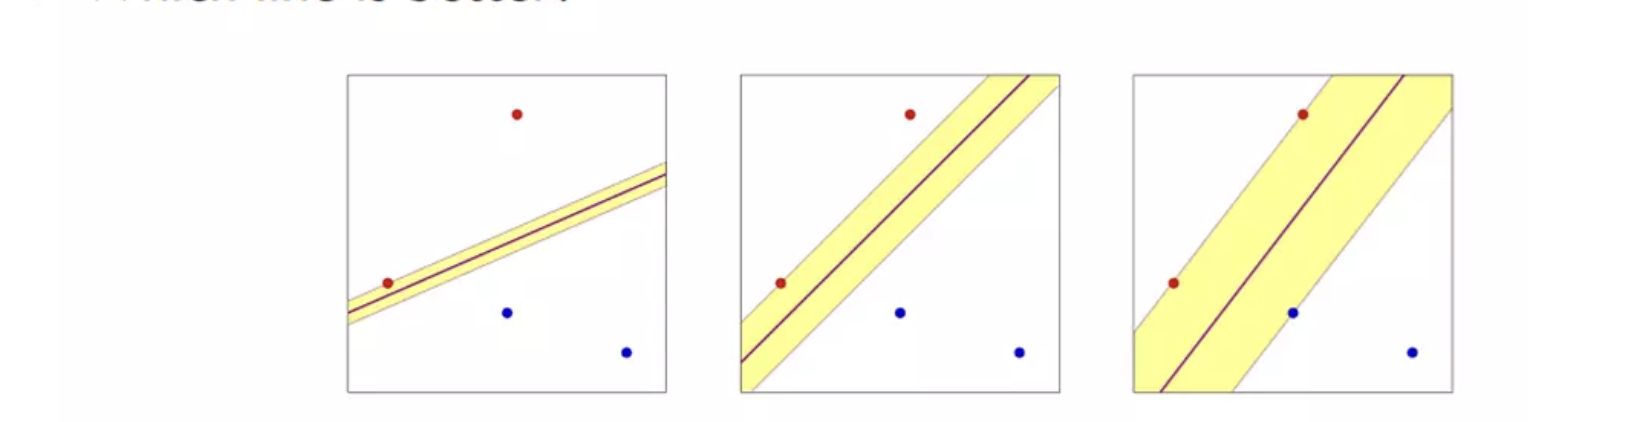
<center>Figure 1: Hyperplane + their margins, Adopted from [1]</center>

In the figure above we have considered three different hyperplanes. For example in the first picture in the left we move it on it's own direction(the line's slope stay the same and only $w_0$ change), **margin** says that how much we can move our hyperplane in it's own direction to still have correct classified data samples.

Now with the descriptions above it's very better to have **bigger** margins, and as a matter of fact SVM tries to choose a hyperplane that maximizes this **margin**.<br>

Now the question is how a bigger margin is helpful? The answer is easy: better **generalization** for unseen data, and makes classes better classified.

> Our assumption 'til further notice is that our samples are linearly separable.

SVM finds the solution with maximum margin. The *solution* is a hyperplane that is farthest from all training samples.

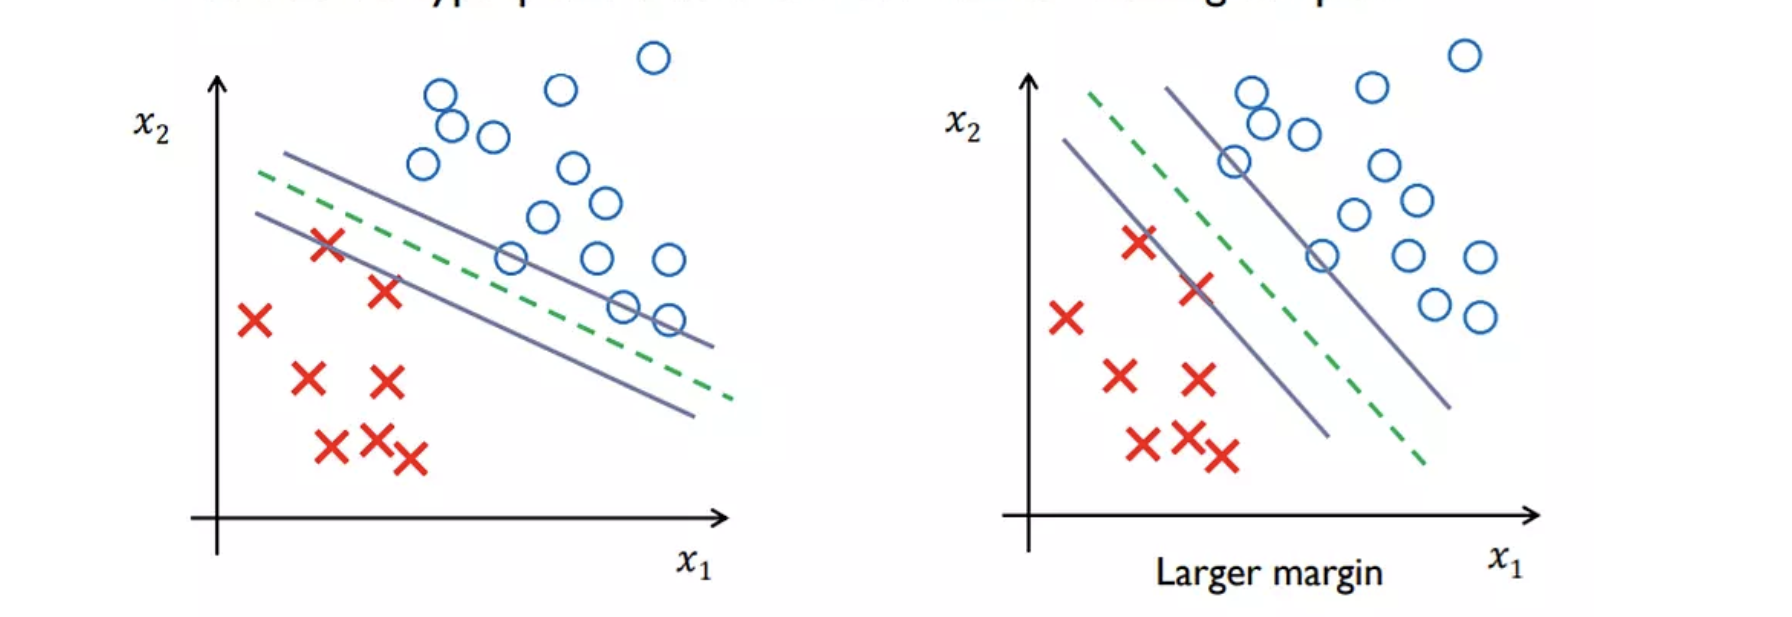
<center>Figure 2: SVM's solution; bigger margined hyperplane, Adopted from [1]</center>
<br>

Now If you remembered from the previous concepts we have a hyperplane with the below equation for linearly classify between data samples:

$$w^Tx + w_0 = 0$$

Now we know that SVM's purpose is to find the optimal parameters ($w$, $w_0$) to have a hyperplane with max margin.

For the sake of the problem we define an assumption and kind of normalize the values of $w$ and $w_0$ based on that, we assumes that if we put the closest data point($x^{(n)}$) in the hyperplane's equation, it's absoluted and distance value would equal to $1$:

$$|w^Tx^{(n)} + w_0| = 1$$

`Just have the concept below as something in paranthesis`

##### Distance between a data point($x^{(n)}$) and a hyperplane in features space:

$$\text{Distance} = \frac{|w^Tx^{(n)} + w_0|}{||w||}$$

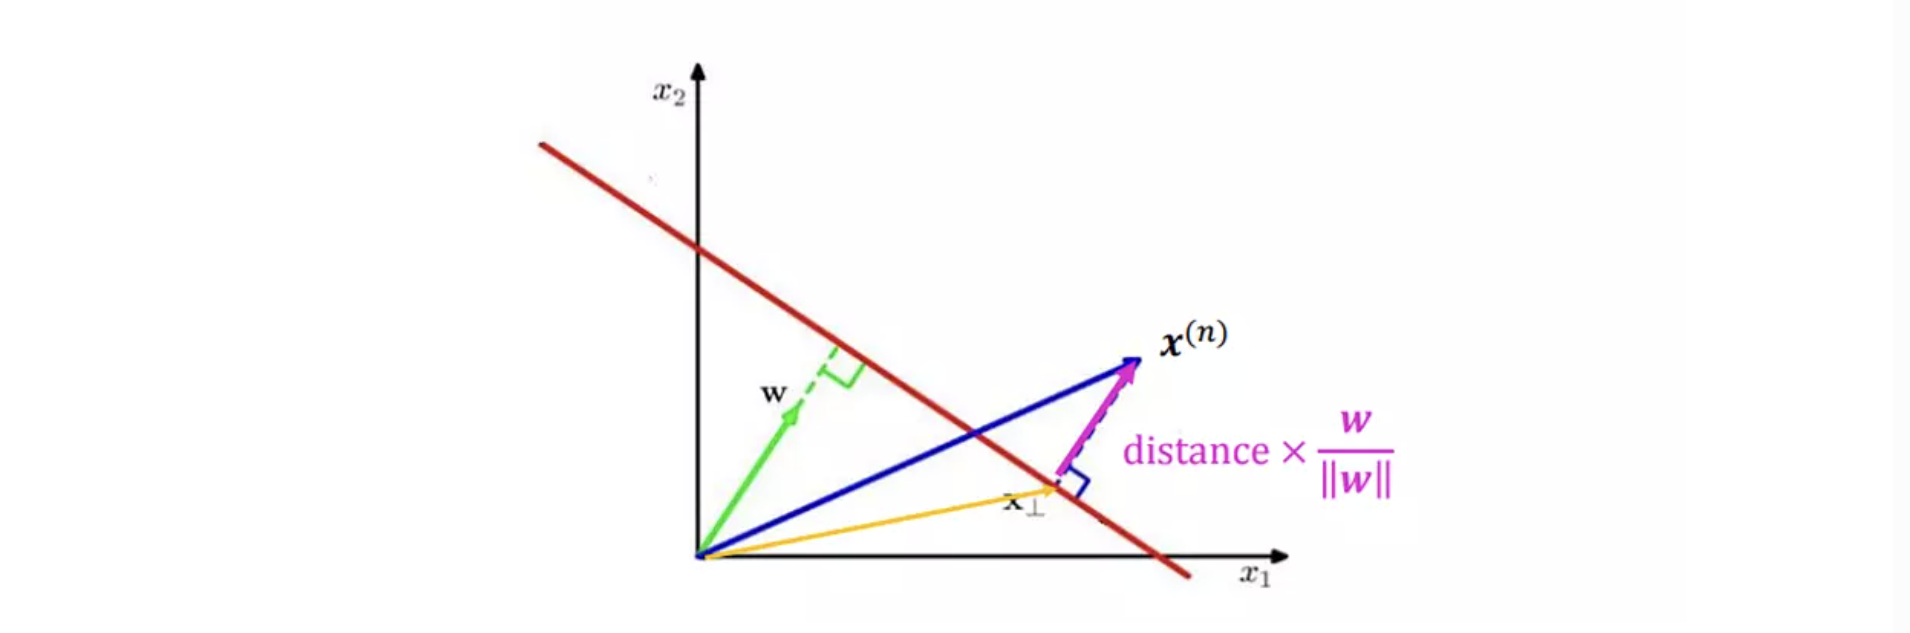
<center>Figure 3: Adopted from [1]</center>
<br>

We calculate the distance of $x$ from origin with sum of the distance of $x$ from hyperplane and it's perpendicular distance:

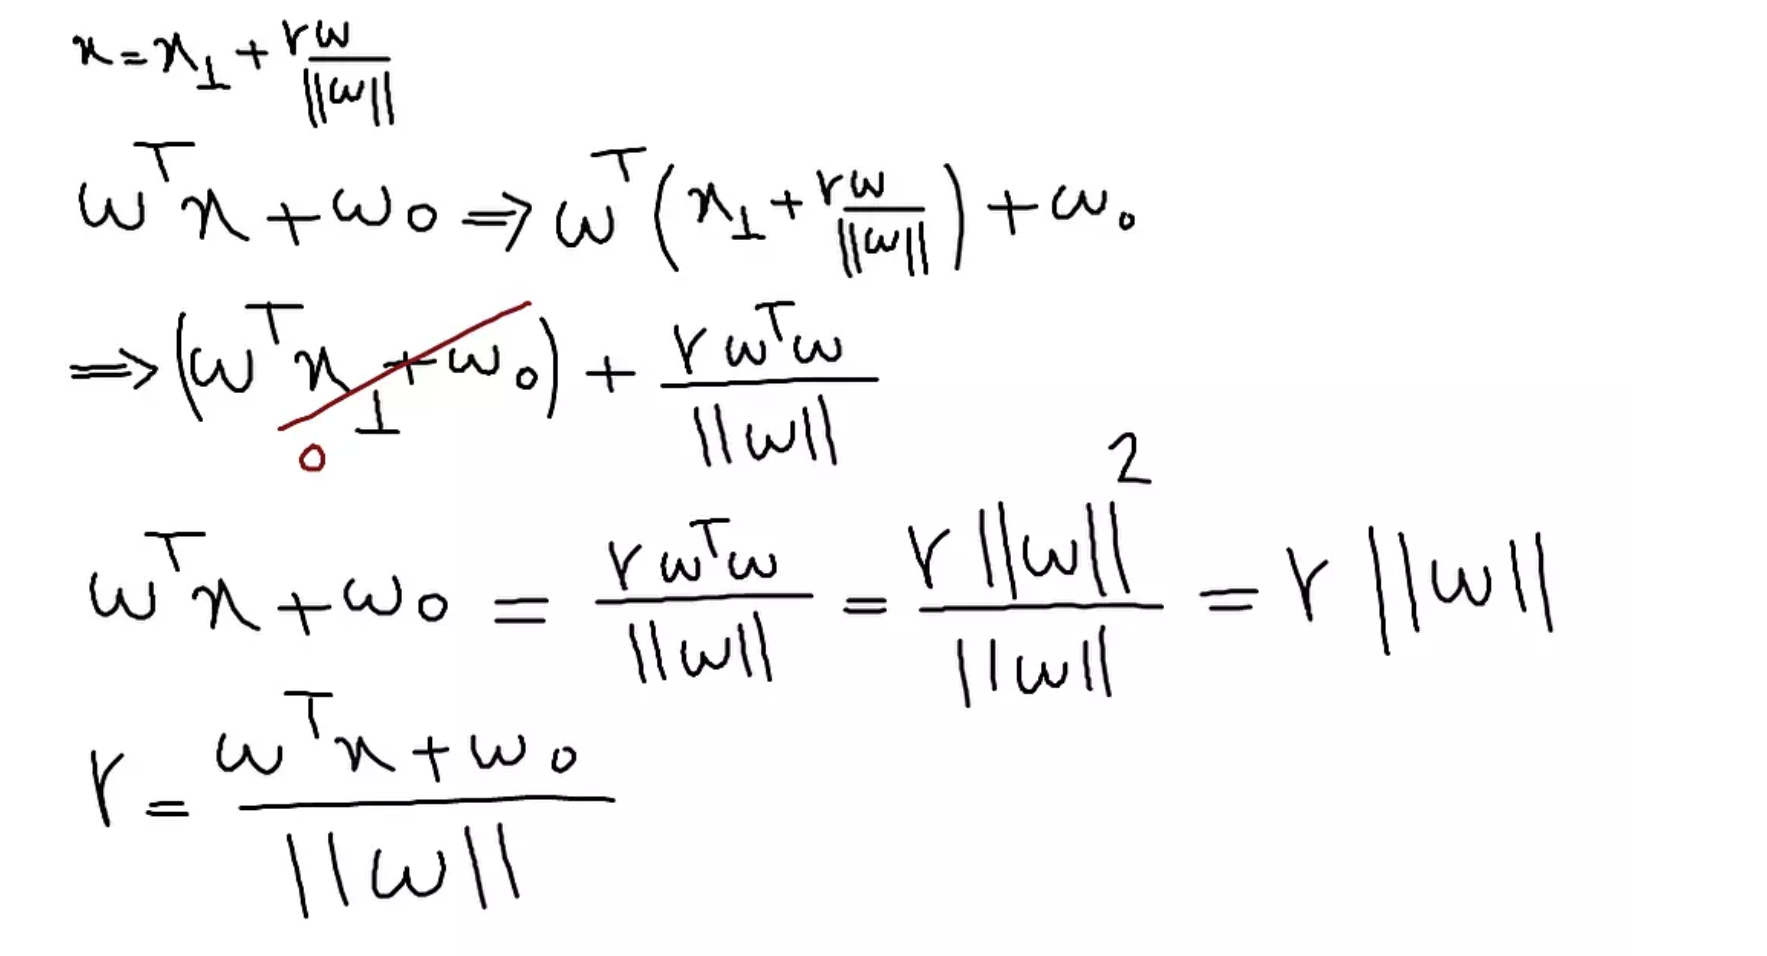
<center>Figure 4: Formulas for above equation, Adopted from [2]</center>

## SVM Optimization Problem:

Our assumption in this problem was that our samples are linearly classifiable. We considered $x^{(n)}$ is the closest data point to the hyperplane and set and normalize $w$ and $w_0$ so that if we put $x^{(n)}$ in the hyperplane's equation, the final result would be $1$. 

Above we saw how euclidean distance to a hyperplane's equation and let's see what happens if we put $x^{(n)}$ in that equation:

$$\text{distance} = \frac{|w^Tx^{(n)} + w_0|}{||w||}, \; \; |w^Tx^{(n)} + w_0 | = 1 $$
$$\Rightarrow \text{distance} = \underbrace{\frac{1}{||w||}}_{\text{One side of margin}}$$
$$\rightarrow \text{margin} = \frac{2}{||w||}$$

Cause that $x^{(n)}$ is the closest data sample to the hyperplane, It applies for both side of the hyperplane, so the distnace of closest data sample to the hyperplane times 2 gives us the margin of the hyperplane:

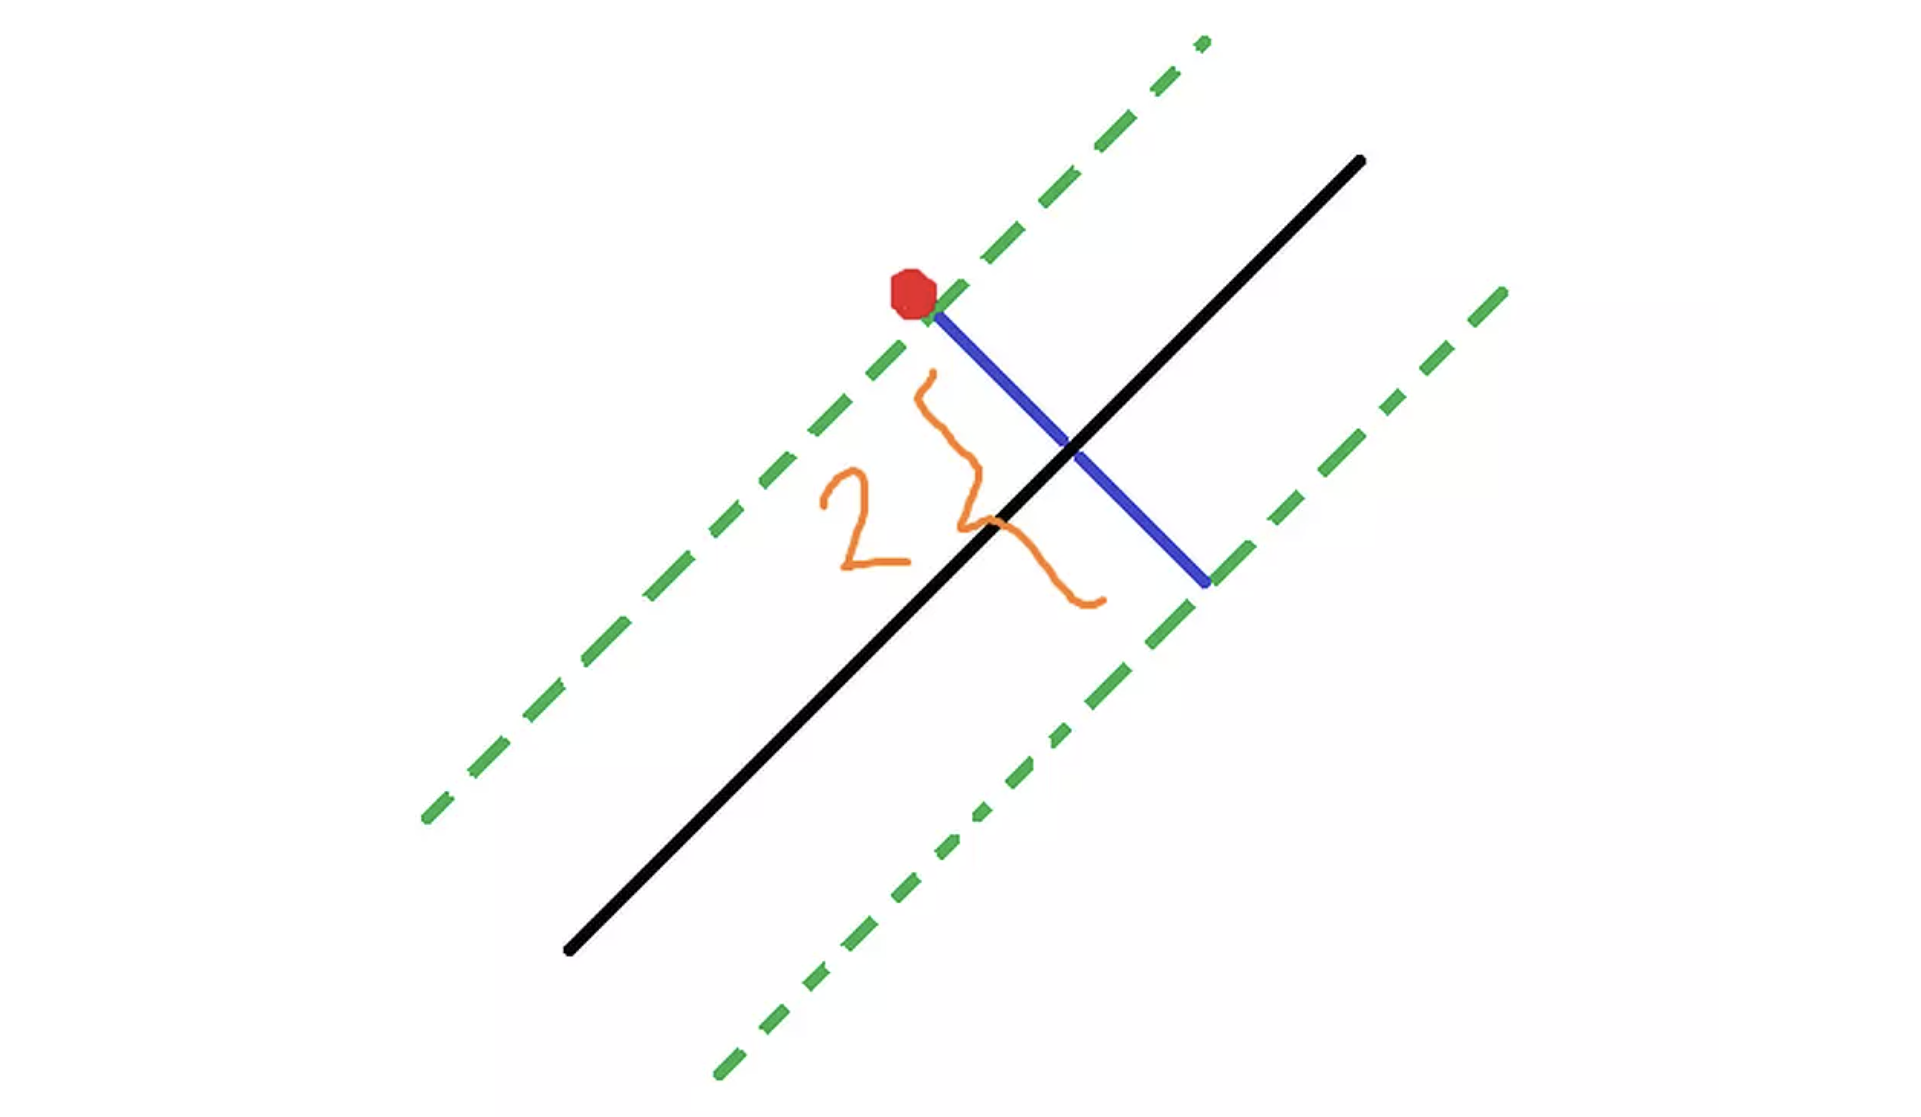
<center>Figure 5: hyperplane's margin, Adopted from [1]</center>
<br>

So the thing we try to optimize is the below equations:
$$\max_{w, w_0} \frac{2}{||w||}$$
$$s.t. \;\;\;\; \min_{n = 1, ..., N} |w^Tx^{(n)} + w_0| = 1$$

In the optimization context this optimization above is in the hard problems and we cannot solve that. So what we should do is to change our constraints into linear constraints, We replace the equation below:

$$|w^Tx^{(n)} + w_0| = y^{(n)}(w^Tx^{(n)} + w_0)$$

Note: If we want to maximize a function, if it is positive, we can maximize it's power 2 and nothing changes:

$$\max_{w, w_0} \frac{2}{||w||} = \max_{w, w_0} \frac{2}{||w||^2}$$

Note: And we also can change $\max$ by reversing the equation:

$$\max_{w, w_0} \frac{2}{||w||^2} = \min_{w, w_0} \frac{||w||^2}{2}$$

So what we try to optimize now is in below:

$$\min_{w, w_0} \frac{||w||^2}{2}$$
$$y^{(n)}(w^Tx^{(n)} + w_0) \geq 1 \;\; n = 1, ..., N$$


Our purpose in these problems is two things:
1. Classify all the data samples in the right way: the prediction ($w^Tx^{(n)} + w_0$) and the real label ($y^{(n)}$) should be the same sign.
2. And then maximize the margin

The optimizatin problem above is a convex Quadratic Programming (QP) problem, so: 
+ There are computationaly efficient packages and tools to solve it
+ It has a **global** minimum (if any)

For solving such optimization problem that we have reached here we need Quadratic Programming approach.

#### Quadratic Programming:

$$\min_{x} \frac{1}{2}x^TQx + c^Tx$$
$$s.t. \;\;\; Ax \leq b$$
$$Ex = d$$

The above form of equations and problems are called Quadratic Programming problems. in which we try to find the value of $x$ such that a Quadratic equation get minimize with some linear equal and not equality constraints.

In the optimization problem that we've got, The *Q* matrix is the *identity matrix*, and *c* is equal to zero. And buch of constraints that we can have. We would give these to tools to solve the problem for us.<br>
Although that we do not solve this optimization problem for SVM directly, as a matter of fact we define a duality for it to solve it much more easily.

**Dual formulation of the SVM:**
We are going to introduce the *dual* SVM problem which is equivalent to the original *primal* problem. The dual problem:
+ is often easier
+ gives us more insights into the optimal hyperplane
+ enable us to exploit the kernel trick.

Before solving the dual SVM problem, first let's see how we're gonna solve a optimization problem with constraint.<br>
Assume that we have a function $f$ and we're looking for the minimum of that function and we've got bunch of equality and not-equality equations. In the optimization context we use **Lagrangian Multipliers** for solving this problem. We form a function that, in addition to being a function of $x$, is also a function of the coefficient for each of the functions that appear in the conditions/constraints.

$$p^* = \min_{x} f(x)$$
$$s.t. \;\;\; g_i(x) \leq 0 \;\; i = 1, ..., m$$
$$h_i(x) = 0 \;\; i = 1, ..., p$$

$$\mathcal{L}(x, \alpha, \lambda) = f(x) + \sum_{i=1}^{m} \alpha_i g_i(x) + \sum_{i=1}^{p} \lambda_i h_i(x)$$

We call $\alpha$ and $\lambda$ **lagrangian multipliers**, and both of them are vectors:

$$\alpha = [\alpha_1, ..., \alpha_m] \\ \lambda = [\lambda_1, ..., \lambda_p]$$

For better understanding this function and these multipliers, assumes that we wanna maximize the function we have formed so far for alpha and lambda values, for alpha there is a bigger than zero constraint.


We wanna classify different regions of the space $x$ and say what the value of lambda is based on that. In two cases where the conditions/constraints are not met, the value of the Lagrange function infinite. When the conditions/constraints are met, the value of the Lagrange function is equal to the value of $f(x)$:

$$\max_{\{\alpha_i \geq 0\}, \{\lambda_i\}} \mathcal{L}(x, \alpha, \lambda) = \begin{cases} \infty & \text{any} \; g_i(x) > 0, \\ \infty & \text{any} \; h_i(x) \neq 0, \\ f(x) & \text{otherwise} \end{cases}$$

Previously we were looking for minimizing function $f$ on a part of space so that the conditions and constraints are met. Instead of that we wanna say that to minimize the maximum of lagrangian function. It kind of mean that we're calculating the value of $f$ in a condition that the constraints are met.

$$p^* = \min_{x} \max_{\{\alpha_i \geq 0\}, \{\lambda_i\}} \mathcal{L}(x, \alpha, \lambda)$$


Now the point is we can swap the positions of `min` and `max` and create a dual for what we saw above that is exactly equivalent.


In general we have:
$$\max_{x}\min_{y}h(x, y) \leq \min_{y}\max_{x} h(x, y)$$

The **primal problem** is:

$$p^* = \min_{x} \max_{\{\alpha_i \geq 0\}, \{\lambda_i\}} \mathcal{L}(x, \alpha, \lambda)$$

The **dual problem** is:

$$d^* = \max_{\{\alpha_i \geq 0\}, \{\lambda_i\}} \min_{x} \mathcal{L}(x, \alpha, \lambda)$$

+ Obtained by swapping the order of min and max
+ $d^* \leq p^*$

> "When the original problem is convex ($f$ and $g$ are convex functions and $h$ is affine), we have strong duality $d^* = p^*$.<br>

Now let's get back to our original problem. In this problem we only have series of inequality constraints. To make this constraints similar to the constraint above (i.e., a condition that becomes negative) we only need to do one shift:

$$\min_{w, w_0} \frac{1}{2} ||w||^2$$
$$s.t. \;\;\; y^{(i)}(w^Tx^{(i)} + w_0) \geq 1 \;\; i = 1, ..., N$$

By incorporating the constraints through lagrangian multipliers, we will have:

$$\min_{w, w_0} \max_{\{\alpha_n \geq 0\}} \{\frac{1}{2} ||w||^2 + \sum_{n=1}^{N} \alpha_n(1 - y^{(i)}(w^Tx^{(i)} + w_0))\}$$

Dual problem(changing the order of min and max in the above problem):

$$\max_{\{\alpha_n \geq 0\}} \min_{w, w_0}  \{\frac{1}{2} ||w||^2 + \sum_{n=1}^{N} \alpha_n(1 - y^{(i)}(w^Tx^{(i)} + w_0))\}$$

$$\max_{\{\alpha_n \geq 0\}} \min_{w, w_0} \mathcal{L}(w, w_0, \alpha)$$

Now let's get into solving the equation. First of all we should solve the `min` part.(How?) We take it's deviation and equal the result to zero and if we reach to a closed form equation the job is done. We take the derivation once based on $w$ and once based on $w_0$.

Derivation based on $w$:

$$\mathcal{L}(w, w_0, \alpha) = \frac{1}{2} ||w||^2 + \sum_{n=1}^{N} \alpha_n(1 - y^{(i)}(w^Tx^{(i)} + w_0))$$

$$\nabla_w \mathcal{L}(w, w_0, \alpha) = 0 \Rightarrow w - \sum_{n=1}^{N} \alpha_n y^{(n)} x^{(n)} = 0$$
$$\Rightarrow w = \sum_{n=1}^{N} \alpha_n y^{(n)} x^{(n)}$$

> The answer we came up with for vector $w$ is to multiply each training sample by its corresponding $y$ and another factor, then add them all together. We came up with a *closed form* equation for $w$

Derivation based on $w_0$:

$$\frac{\partial \mathcal{L}(w, w_0, \alpha)}{\partial w_0} = 0 \Rightarrow -\sum_{n=1}^{N} \alpha_n y^{(n)} = 0$$

> $w_0$ do not appear, so we don't have a *closed form* equation for it, instad, a "global" constraint on $\alpha$ is created.


Now we wanna place what we've came up with in the lagrangian function.

$$w = \sum_{n=1}^{N} \alpha_n y^{(n)} x^{(n)} \;\;\;\;\;\;\;\;\;\;\; \sum_{n=1}^{N} \alpha_n y^{(n)} = 0$$

In the lagrangian, first we multiply $\alpha_n$ to 1 and separate it:

$$\mathcal{L}(w, w_0, \alpha) = \frac{1}{2}w^Tw + \sum_{n=1}^{N} \alpha_n( - y^{(i)}(w^Tx^{(i)} + w_0))$$
$$\mathcal{L}(w, w_0, \alpha) = \sum_{n=1}^{N} \alpha_n$$

And after removing the $w_0$ we have:

$$\mathcal{L}(w, w_0, \alpha) = \frac{1}{2}w^Tw + \sum_{n=1}^{N} \alpha_n( - y^{(i)}(w^Tx^{(i)} ))$$
$$\mathcal{L}(w, w_0, \alpha) = \sum_{n=1}^{N} \alpha_n$$

And finally we get to the equation below:

$$\mathcal{L}(w, w_0, \alpha) = \sum_{n=1}^{N} \alpha_n - \frac{1}{2}\sum_{n=1}^{N}\sum_{m=1}^{N} \alpha_n \alpha_m y^{(n)} y^{(m)} x^{(n)^T} x^{(m)}$$

$$\text{Maximize w.r.t. } \alpha \text{ subject to } \alpha_n \geq 0 \text{ for } n = 1, ..., N \text{ and } \sum_{n=1}^{N} \alpha_n y^{(n)} = 0$$

So far we have obtained the dual form of the relation for SVM. Since it is a QP problem, its solution is very simple with the tools. But why did we calculate the dual at all? Because we can see more intuition in this relation, which we will examine later.

**Hard-margin SVM: Dual problem:**

$$\max_{\alpha} \{\sum_{n=1}^{N} \alpha_n - \frac{1}{2}\sum_{n=1}^{N}\sum_{m=1}^{N} \alpha_n \alpha_m y^{(n)} y^{(m)} x^{(n)^T} x^{(m)}\}$$
$$\text{Subject to} \;\; \sum_{n=1}^{N} \alpha_n y^{(n)} = 0$$
$$\alpha_n \geq 0 \;\; n = 1, ..., N$$

> It is a convex QP

We can rewrite the above expression as follows. We were looking to find the maximum of $f$ , which is equivalent to finding the negative minimum of $f$. On the other hand, we can write the product of $y$ and $x$ as a matrix. What about the first term of above expression? It means taht we're multiplying the value of $\alpha(n)$ by 1.

$$\min_{a} \frac{1}{2} \alpha^T \begin{pmatrix} y^{(1)}y^{(1)}x^{(1)^T}x^{(1)} & ... & y^{(1)}y^{(N)}x^{(1)^T}x^{(N)} \\ ... & ... & ... \\ y^{(N)}y^{(1)}x^{(N)^T}x^{(1)} & ... & y^{(N)}y^{(N)}x^{(N)^T}x^{(N)} \end{pmatrix} \alpha + (1)^T \alpha$$
$$\text{s.t.} -\alpha \leq 0 \\ y^T\alpha = 0$$

Now assume that we have solve this problem, how should we find the hyperplane?
<br>
 

##### Finding the Hyperplane:

After finding $alpha$ by QP, we find $w$:

$$w = \sum_{n=1}^{N} \alpha_n y^{(n)} x^{(n)}$$

Now how should we find the value of $w_0$? We say that if we put the closest data point in the hyperplane's equation it should be equal to one, we can do this to find $w_0$, but wait a bit we're gonna get introduce to the concept of support vector and then we discuss this.

Now assume that we want to minimize $f$ and we have considered some constraints for it. And we form a lagrangian function for it too. Now we want to find the necessary conditions for the solutions to the problem on the right. These are a series of conditions that we want to use to find the optimal solution. These conditions are called KKT conditions.

$$\min_{x} f(x) \\ \text{s.t. } g_i(x) \leq \;\; i = 1, ..., m$$
$$\mathcal(L)(x, \alpha) = f(x) + \sum \alpha_i g_i(x) \\ \\ \text{In general, the optimal } x^*, \alpha^* \text{ satisfies KKT conditions: }$$
$$\nabla_x \mathcal{L}(x, \alpha)|_{x^*, \alpha^*} = 0 \\ \\ \alpha_i^* \geq 0 \;\;\; i = 1, ..., m \\ \\ g_i(x^*) \leq 0 \;\;\; i = 1, ..., m \\ \\ \alpha_i^*g_i(x^*) = 0 \;\;\; i = 1, ..., m$$


Now let's write the KKT conditions for the problem we were having. We will examine its details and intuition later.

##### Karush-Kuhn-Tucker (KKT) conditions:

Necessary conditions for the solution $[w^*, w_0^*, \alpha^*]$:

$$\nabla_w \mathcal{L}(w, w_0, \alpha)|_{w^*, w_0^*, \alpha^*} = 0$$
$$\frac{\partial{\mathcal{L}(w, w_0, \alpha)}}{\partial{w_0}}|_{w^*, w_0^*, \alpha^*} = 0$$
$$\alpha_n^* \geq 0 \;\;\; i = 1, ..., N$$
$$y^{(n)}(w^{*^T}x^{(n)} + w_0^*) \geq 1 \;\;\; n = 1, ..., N$$
$$\alpha_i^*(1 - y^{(n)}(w^{*^T}x^{(n)} + w_0^*)) = 0 \;\;\; n = 1, ..., N$$

Now let's examine different situations:

+ **Inactive** constraint: $y^{(n)}(w^{*^T}x^{(n)} + w_0^*) > 1$ 

    In this situation to meet the KKT conditions in above $\alpha_n = 0$ and thus $x^{(i)}$ is not a support vector.

    > This situation means that our data is not on the margin. It is either on the top of the margin or on the bottom of it and away from it.

+ **Active** constraing:  $y^{(n)}(w^{*^T}x^{(n)} + w_0^*) = 1$ 

    In this istuation to meet the KKT conditions in above $\alpha_n$ can be greater than 0 and thus $x^{(i)}$ can be a support vector

    > This case means that data must be on the margin, If alpha is greater than 0, it means that the data definitely falls on the margin.

**We call points where the $\alpha$ value is greater than 0 support vectors. Why? Because we use them to define the boundary**

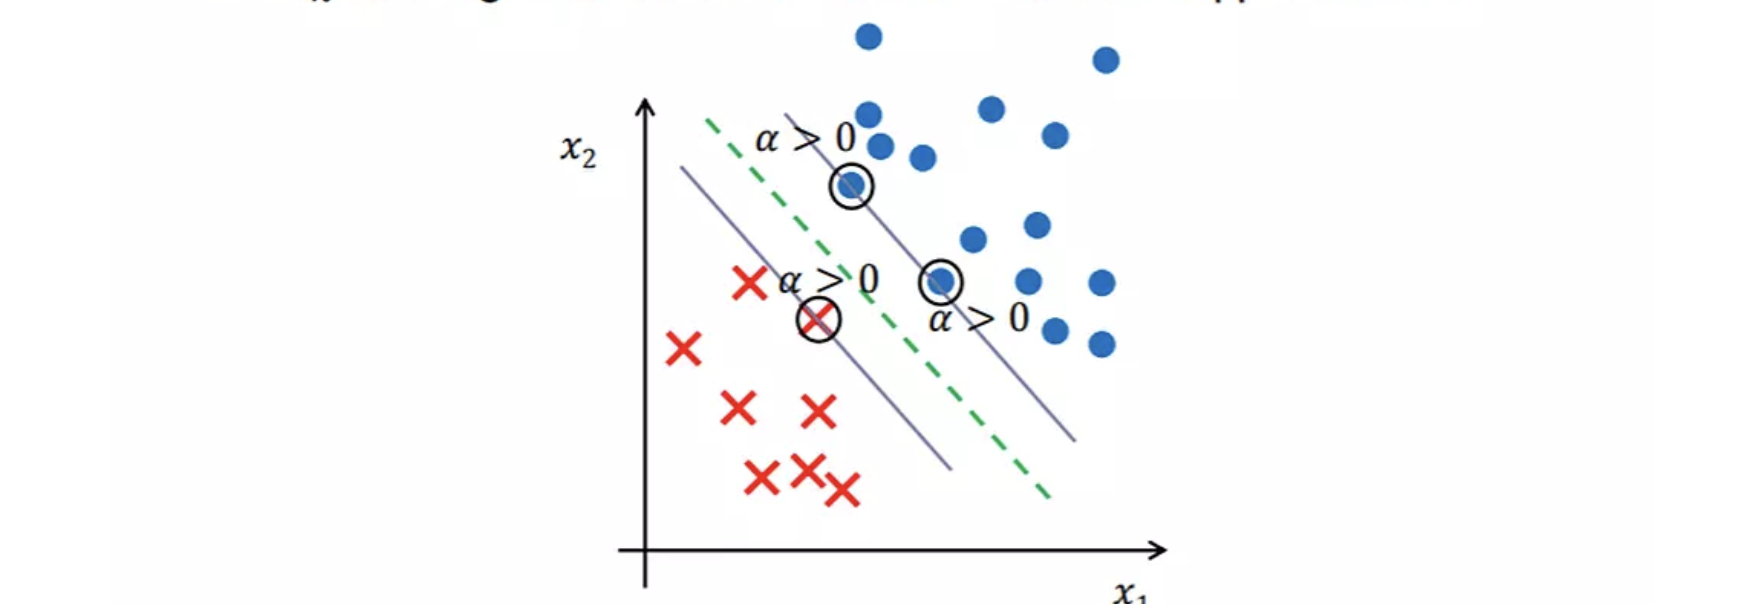
<center>Figure 6: Support Vector boundary, Adopted from [1]</center>


Now we're able to calculate the values of $w_0$ using **support vector**.

#### Support Vector:

Support Vectors (SVs) = $\{x^{(n)} | \alpha_n > 0\}$

The **direction** of hyperplane can be found only based on support vectors:

$$w = \sum_{\alpha_n > 0} \alpha_n y^{(n)}x^{(n)}$$

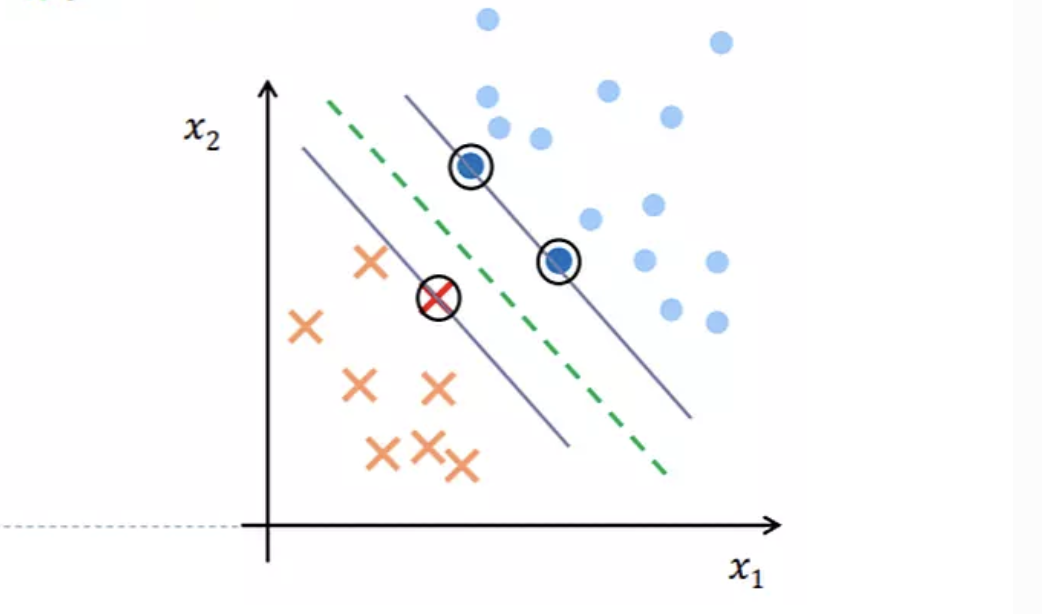
<center>Figure 7: support vector, Adopted from [1]</center>

We take one of the alpha values that is greater than 0 (support vector). On the other hand, we know that if a point is on the margin, the following relationship holds for it. So we can easily calculate the value of $w_0$.


After finding $\alpha$ by QP, we find $w$:

$$w = \sum_{n=1}^{N} \alpha_n y^{(n)}x^{(n)}$$

Now how to find $w_0$? 
+ Each of the samples that has $alhpa_s > 0$ is on the margin, thus we solve for $w_0$ using any SVs:
$$|w^Tx^{(s)} + w_0| = 1$$
$$y^{(s)}(w^Tx^{(s)} + w_0) = 1$$
$$\Rightarrow w_0 = y^{(s)} - w^Tx^{(s)}$$

Now we want to find the decision rule or the boundary, what does it mean? If a data is positive it get to the positive side and if negative it get to the negative side..

#### Classifying new samples using only SVs

Any data that appears in the classifier relation(i.e., wherever  we have x) is in the form of an inner product of two points. This helps us to build more complex clusters later in the kernel discussion instead of inner products.

Classifying of a new sample $x$:

$$\hat{y} = sign(w_0 + w^Tx)$$
$$\hat{y} = sign(w_0 + (\sum_{\alpha > 0} \alpha_n y^{(n)} x^{(n)})^T x)$$
$$\hat{y} = sign(\underbrace{y^{(s)} - \sum_{\alpha_n > 0} \alpha_n y^{(n)}x^{(n)^T}x^{(s)}}_{w_0} +  \sum_{\alpha_n > 0} \alpha_ny^{(n)} x^{(n)^T}x) $$

> Support vectors are sufficient to predict labels of new samples. 

> The classifier is based on the expansion in terms of dot products of $x$ with support vectors

#### Dual Problem:

So far the optimization problem we have calculated has the following form:

$$\max_{\alpha} \{\sum_{n=1}^{N} \alpha_n - \frac{1}{2}\sum_{n=1}^{N}\sum_{m=1}^{N} \alpha_n \alpha_m y^{(n)} y^{(m)} x^{(n)^T} x^{(m)}\}$$
$$\text{Subject to} \;\; \sum_{n=1}^{N} \alpha_n y^{(n)} = 0$$
$$\alpha_n \geq 0 \;\; n = 1, ..., N$$

+ Only the dot product of each pair of training data appears in the optimization problem, an important property that is helpful to extend to non-linear SVM.

As we saw earlier in the linear and nonlinear regression problem, to find the appropriate boundary, we first changed teh space, crossed the line, and then returned to the original state. Now we wanna similar to that definition here. Assume that our data samples are separable with a circle, we devide data into inside the circle and outside the circle groups. Now if we perform a transformation on the data, we will have the value phi(x) instead of x. The parameters remain constant and do not change. What does that mean? It means that the change in dimensions and space has nothing to do with the number and value of the parameters. The only problem that exists and complicates the matter is the complexity of calculating the inner product. But later we will see that this complexity can also be reduced by methods, even in very high dimensions.

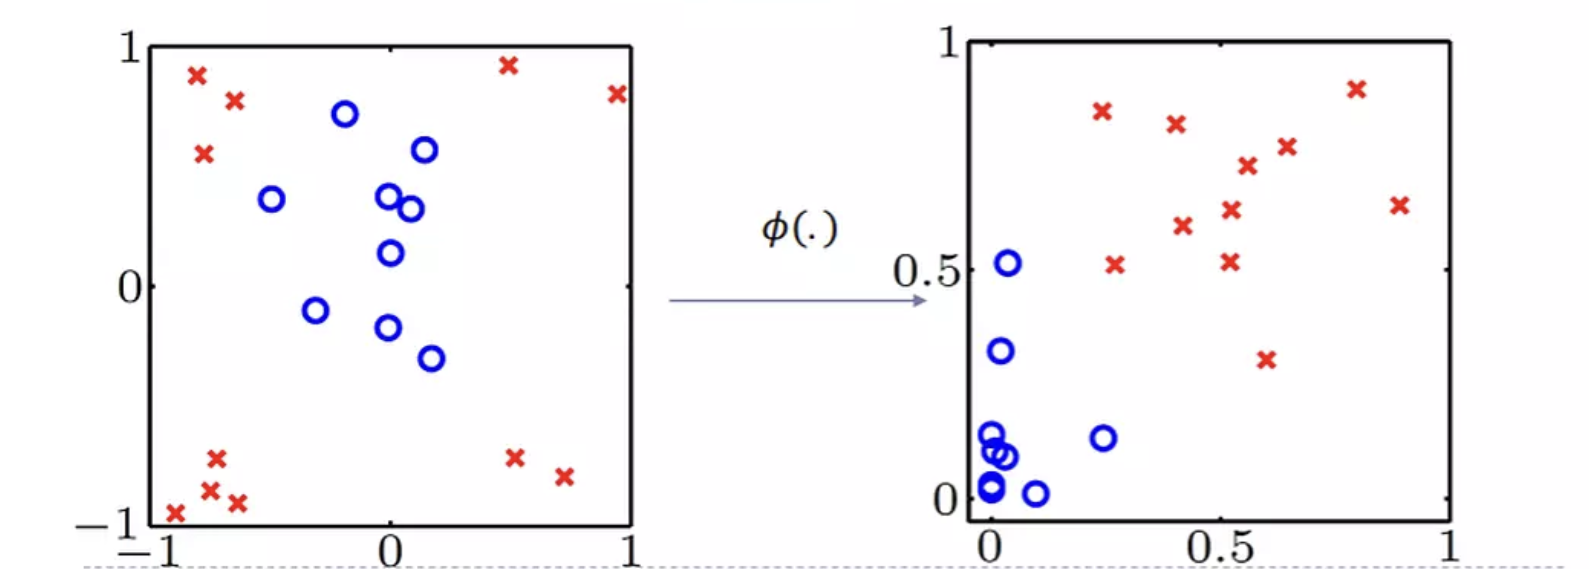
<center>Figure 8: non-linear classification, Adopted from [1]</center>

##### Beyond Linear separability:

We may have data that are not able to be classified linearly, or they may be linearly separable but there be noise in our samples, so we should have methods for it to maximize margin.

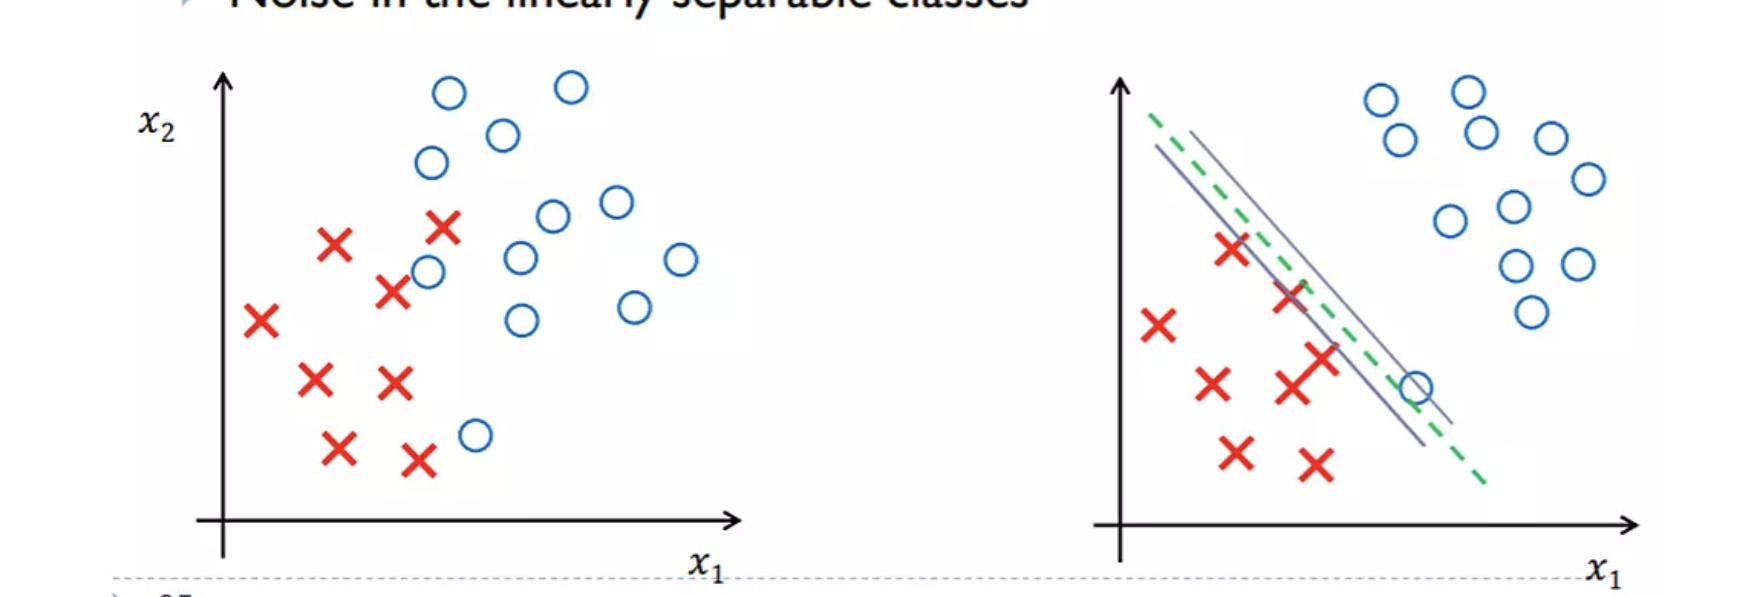
<center>Figure 9: Noise in classifying data, Adopted from [1]</center>

What we've talked about so far was **Hard Margin**. From now on we're gonna talk about **Soft Margin**. In short we have made our conditions/contraints a bit softer, It's like instead of saying that data get place exactly up and down the hyperplane it's ok that some data samples get misclassified.

From the equation of the dual we conclude that our parameters have nothing to do with our samples and their dimension and we can change the space.<br>
The tools that we discussed previuosly can solve the dual problem for us. However, the problem is that even if this problem has no solution, the tool returns an answer and does not say that the problem has no solution. The answer it gives us will probably be a **random** answer.<br>

+ Now when do we say that the dual problem has no solution?

    The dual problem has no solution if our samples do not be linearly separable.

+ Now how can we understand that the tool's answers is the correct solution for the problem or not?

    We can replace the $\alpha$ vector that it gives us as the solution in the equation we have, and compare the resulted/predicted $y$ with the actual $y$. If they were close we can tell that the answer it gave us was true and data are linearly separable.

Now what should we do with data which are not linearly separable? Or data are linearly separable but we have noise? We have a concept called **soft margin**.

### Soft Margin

What we've been using so far was **hard margin** and it did not let any data to get in the margin area, but in **soft margin** we give this permission so data can get into the margin's area.<br>

Now for understanding of how we're working and for evaluation we define a cost or loss function, to evaluate how much error occurred for the data that entered the marginal space. The symbol of $\xi$ shows us how much each sample have passed through margin and got closer to the line(decision boundary). The purpose of optimization problem that we've got here is to minimize $\xi$ for all samples.

The margine violation amount $\xi (\xi \geq 0):$

$$y^{(n)} (w^Tx^{(n)} + w_0) \geq 1 - \xi_n$$
$$\text{Total Violation: } \sum_{n=1}^{N} \xi_n$$

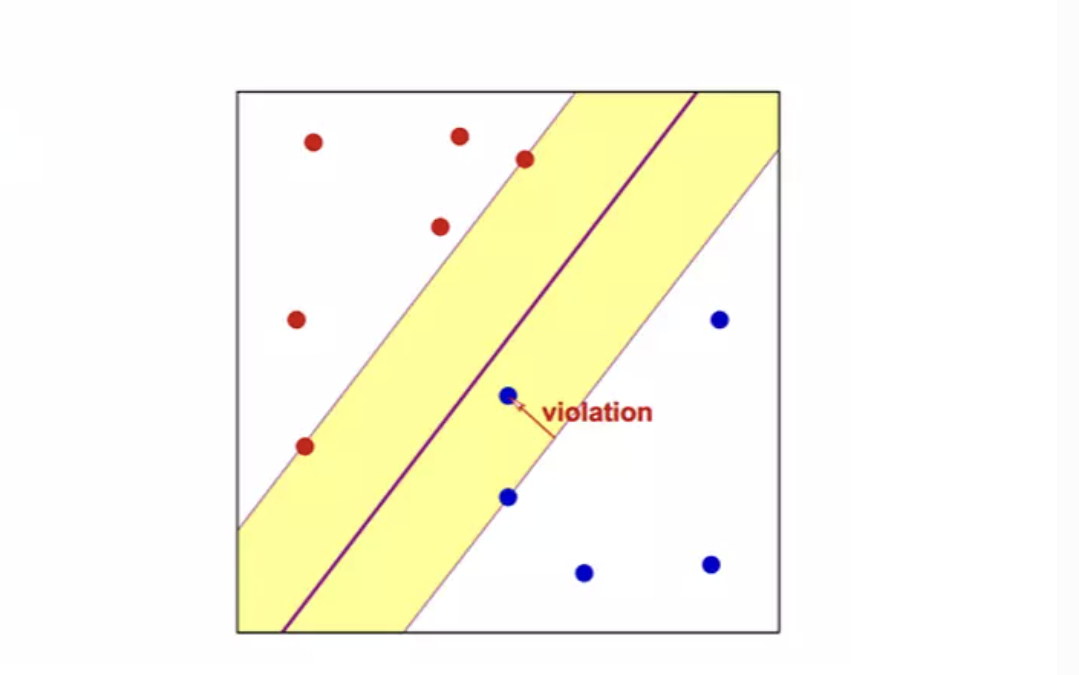
<center>Figure 10: Margin violation, Adopted from [1]</center>
<br>

The optimization problem that we've got here is very much like the **hard margin**.<br>
SVM with slack variables: allows samples to fall within the margin, but penalize them:

$$\min_{w, w_0, \{\xi_n\}_{n=1}^{N}} \frac{1}{2} ||w||^2 + C \sum_{n=1}^{N} \xi_n$$
$$\text{s.t. } \;\;\; y^{(n)}(w^Tx^{(n)} + w_0) \geq 1 - \xi_n \;\;\; n = 1, ..., N \\ \xi \geq 0$$

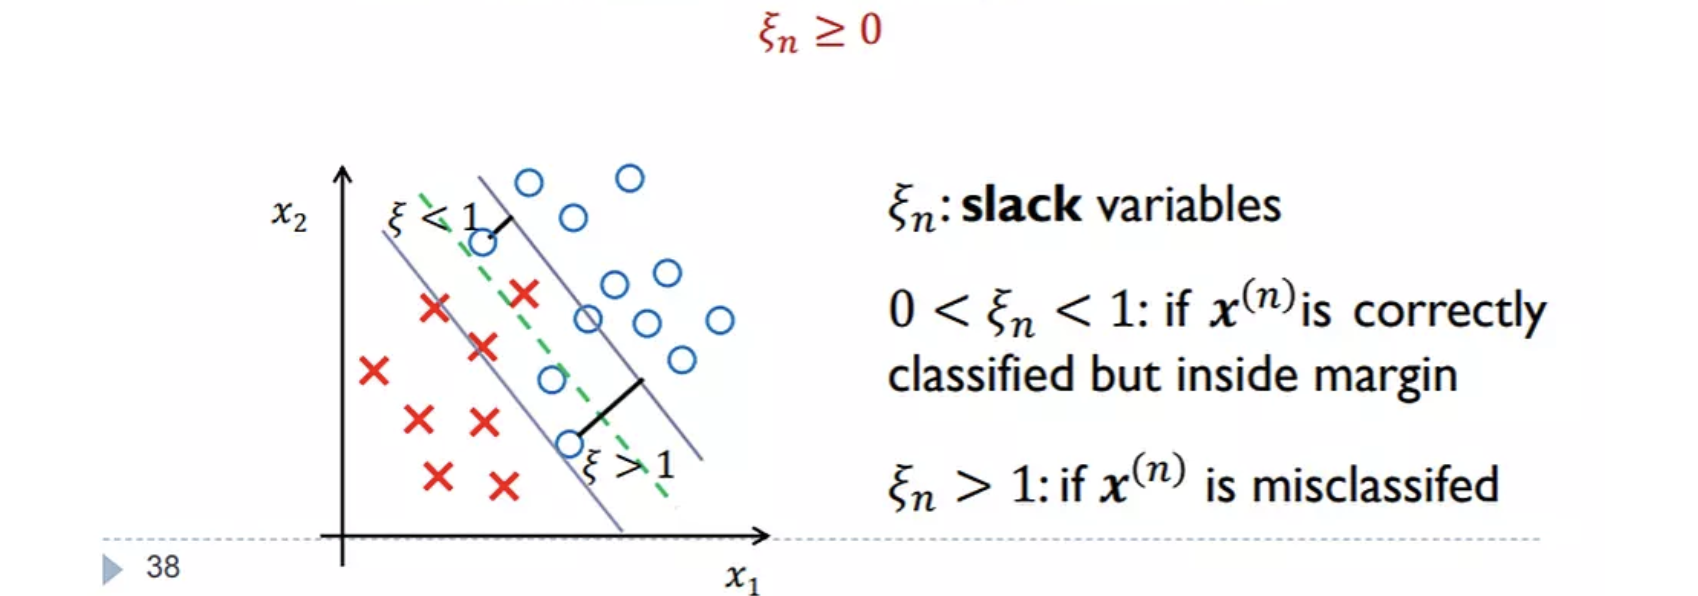
<center>Figure 11: Slack variable and it's value based on the classification it made, Adopted from [1]</center>
<br>

Our purpose is to minimize the value of margin's $\xi$ and yet maximize margin's value. In the matter of optimization our problem would become a QP problem and we solve it using it's dual. 

In **soft-margin SVM** we've got:

+ Linear penalty (hinge loss) for a sample if it is `misclassified` or `lied` in the margin.
+ Tries to maintain $\xi_n$ small while maximizing the margin.
+ always finds a solution (as opposed to hard-margin SVM)
+ more robust to the outliers.
+ Soft margin problem is still a **convex** QP.

In the equation for margin that we wanted to minimize, we have a parameter $C$:
$$\min_{w, w_0, \{\xi_n\}_{n=1}^{N}} \frac{1}{2} ||w||^2 + C \sum_{n=1}^{N} \xi_n$$

**Parameter $C$**:

What happens if the value of parameter $C$ gets too large? It means that we want our data to avoid margin boudaries and do not get into the margin's space as much as possible. When it's value gets infinity it kind of means that our problem is **hard margin**. And in the condition that the value of $C$ is 0, data can spread out however they like nad obviuosly it is not a good thing.

$C$ is a tradeoff parameter:
+ Small $C$ allows margin constraints to be **easily** ignored. 
    + Large margin.
+ Large $C$ makes constraints hard to ignore.
    + narrow margin.

+ $C \rightarrow \infty$ enforces all constraints => **hard margin**.

+ $C$ can be determined using a technique like **cross validation**.

Just for a clarification, if you remembered from previous loss functions we had a loss calculator and a regularization term, If we look into the function that we've got in above that we wanna minimize the $\frac{1}{2} ||w||^2$ is like that regularization term and the $\xi_n$ is our loss and the sum of samples' losses which is the $C\sum_{n=1}^{N} \xi_n$ gives us the total cost function which we try to **minimize** it.


We had two constraints for the problem:
$$\text{s.t. } \;\;\; y^{(n)}(w^Tx^{(n)} + w_0) \geq 1 - \xi_n \;\;\; n = 1, ..., N \\ \xi \geq 0$$

Now we combine them and get to the below constraint:

$$\xi_n \geq \max{(0, 1 - y^{(n)}(w^Tx^{(n)} + w_0))}$$

We said that we wanna minimize the cost function $C\sum_{n=1}^{N} \xi_n$ So we wanna get the minimum value for $\xi_n$ and according to the above equation the minimum possible value for $\xi_n$ is:

$$\xi_n = \max{(0, 1 - y^{(n)}(w^Tx^{(n)} + w_0))}$$


It is equivalent to the unconstrained optimization problem:

$$\min_{w, w_0, \{\xi_n\}_{n=1}^{N}} \frac{1}{2} ||w||^2 + C \sum_{n=1}^{N} \max{(0, 1 - y^{(n)}(w^Tx^{(n)} + w_0))}$$

Now if we plot the loss function, we get to the below plot:

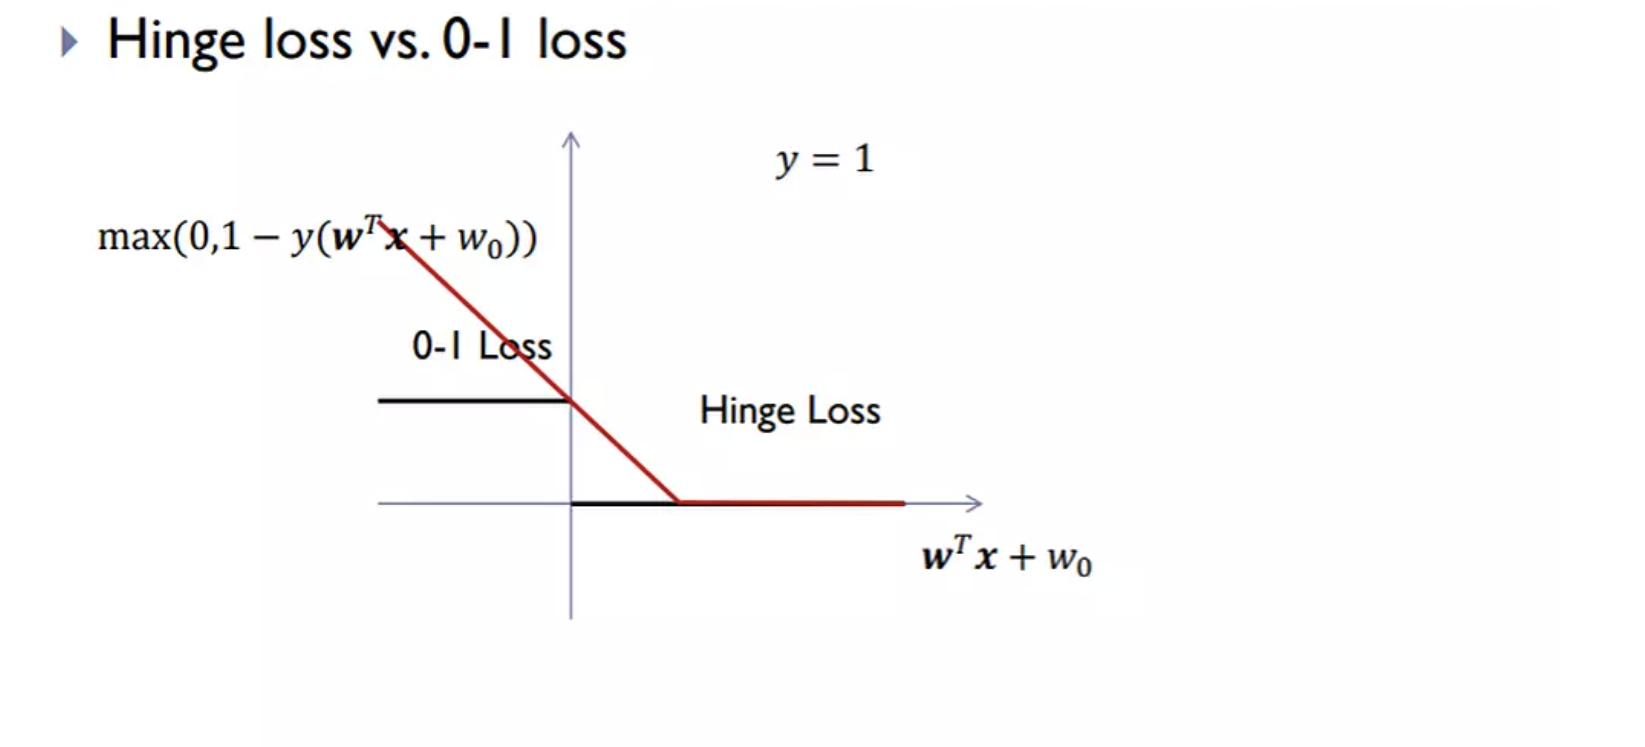
<center>Figure 12: SVM loss function, Adopted from [1]</center>
<br>

> Those that classified correctly and didn't fall into the margin's boundary has zero loss. Those that are in the margin area are in the positive part of the graph and has some loss, and those that are classified incorrectly are on the left side of the graph.

Now we write the problems dual like the previous problem:

$$\mathcal{L}(w, w_0, \xi, \alpha, \beta) = \frac{1}{2} ||w||^2 + C\sum_{n=1}^{N} \xi_n \\ + \sum_{n=1}^{N} \alpha_n(1 - \xi_n - y^{(n)}(w^Tx^{(n)} + w_0)) \\ - \sum_{n=1}^{N} \beta_n \xi_n$$

> We tend to Minimize w.r.t. $w$, $w_0$, $\xi$ and maximize w.r.t. $\alpha_n \geq 0$ and $\beta_n \geq 0$

Now we tend to minimize the equation based on three main parameters($w, w_0, \xi$) and maximize the problem using the lagrangian multipliers($\alpha, \beta$).


##### Lagrange Formulation:

$$\mathcal{L}(w, w_0, \xi, \alpha, \beta) = \frac{1}{2} ||w||^2 + C\sum_{n=1}^{N} \xi_n \\ + \sum_{n=1}^{N} \alpha_n(1 - \xi_n - y^{(n)}(w^Tx^{(n)} + w_0)) \\ - \sum_{n=1}^{N} \beta_n \xi_n$$

$$\nabla_w \mathcal{L}(w, w_0, \xi, \alpha, \beta) = 0 \Rightarrow w - \sum_{n=1}^{N} \alpha_n y^{(n)} x^{(n)} = 0 \\ \Rightarrow w = \sum_{n=1}^{N} \alpha_n y^{(n)} x^{(n)}$$
<br>

$$\frac{\partial{\mathcal{L}(w, w_0, \xi, \alpha, \beta)}}{\partial{w_0}} = 0 \Rightarrow -\sum_{n=1}^{N} \alpha_n y^{(n)} = 0$$
<br>

$$\frac{\partial{\mathcal{L}(w, w_0, \xi, \alpha, \beta)}}{\partial{\xi}} = 0 \Rightarrow C - \alpha_n - \beta_n = 0$$

$$\mathcal{L}(w, w_0, \xi, \alpha, \beta) = \frac{1}{2} ||w||^2 + \sum_{n=1}^{N} \alpha_n + \sum_{n=1}^{N} \xi_n(-\alpha_n -\beta_n + C)$$

The optimization problem resemble the previous one that we had in hard margin, the only difference is the constraint we have on the $\alpha$, In the previous problem $\alpha$ wes greater equal to 0:

$$\max_{\alpha} \{\sum_{n=1}^{N} \alpha_n - \frac{1}{2}\sum_{n=1}^{N}\sum_{m=1}^{N} \alpha_n \alpha_m y^{(n)} y^{(m)} x^{(n)^T} x^{(m)}\}$$
$$\text{Subject to} \;\; \sum_{n=1}^{N} \alpha_n y^{(n)} = 0 \\ 0 \leq \alpha_n \leq C \;\;\; n = 1, ..., N$$

Some heads up:
+ We have removed $\beta_n$ by replacing it with $C - \alpha_n$ and thus we knew that $\beta_n \geq 0$ so we know that $C - \alpha_n \geq 0$.

+ And after solving the above QP we now $w$ is find as:
$$w = \sum_{n=1}^{N} \alpha_n y^{(n)} x^{(n)}$$

Now we check different situations and conditions and see the intuition it represents.

Based on KKT condition that we explained above if:
+ $y^{(n)}(w^Tx^{(n)} + w_0) > 1$ to fulfil the KKT condition ($\alpha^*g(x^*) = 0$) the $\alpha$ should be equal to zero $\alpha =  0$
+ $y^{(n)}(w^Tx^{(n)} + w_0) = 1$ Then  $\alpha$ can be greater than zero and smaller equal than C: $0 < \alpha \leq C$

Now let's see where does the data sample fall for different values of $\alpha_n$:
+ Support Vector: $\alpha_n > 0$:
    + If $0 < \alpha_n < C$ (**margin** support vector), SVs exactly on the margin
        + $y^{(n)}(w^Tx^{(n)} + w_0) = 1 \;\;\;\;\;\;\;\;\;\;\; (\xi_n = 0)$
    + If $\alpha = C$ (**non-margin** support vector), SVs on or over the margin (this includes misclassified samples too):
        + $y^{(n)}(w^Tx^{(n)} + w_0) < 1 \;\;\;\;\;\;\;\;\;\;\; (\xi_n > 0)$

+ Just remember the fact that:
$$C - \alpha_n - \beta_n = 0$$

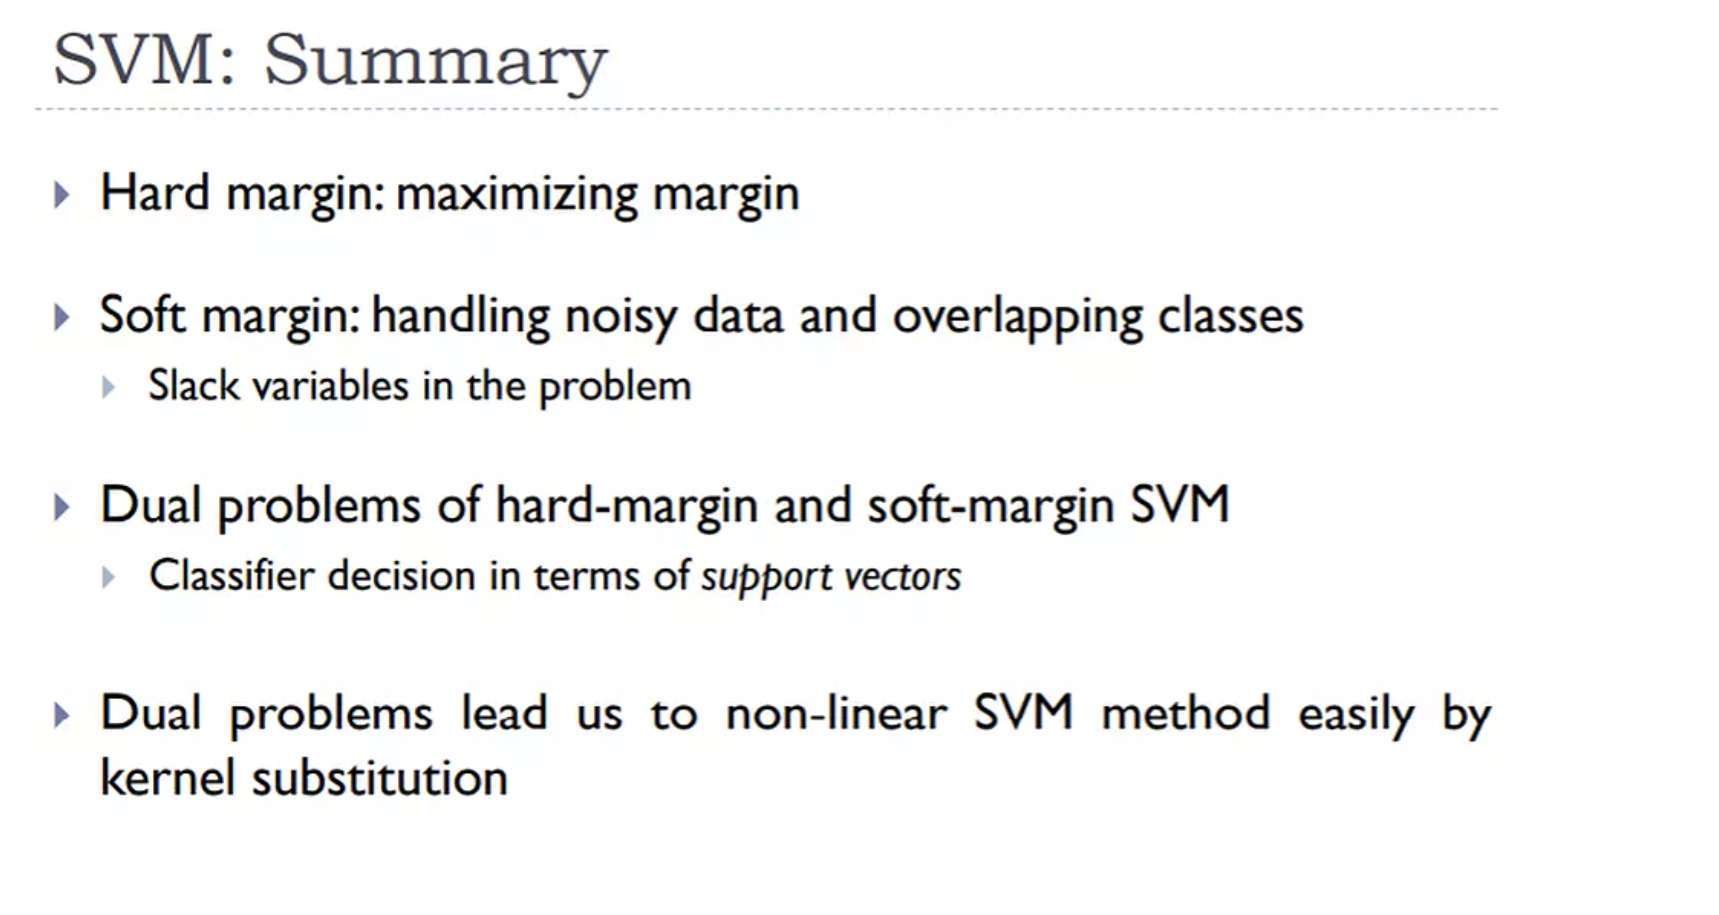
<center>Figure 13: Hard margin and Soft margin summary, Adopted from [1]</center>
<br>

### Kernel

Now consider a situation that data connot get classified using only a linear line. Take two graph below, one of them can be solved using soft-margin but there is not linear approach for the other one as it seems:

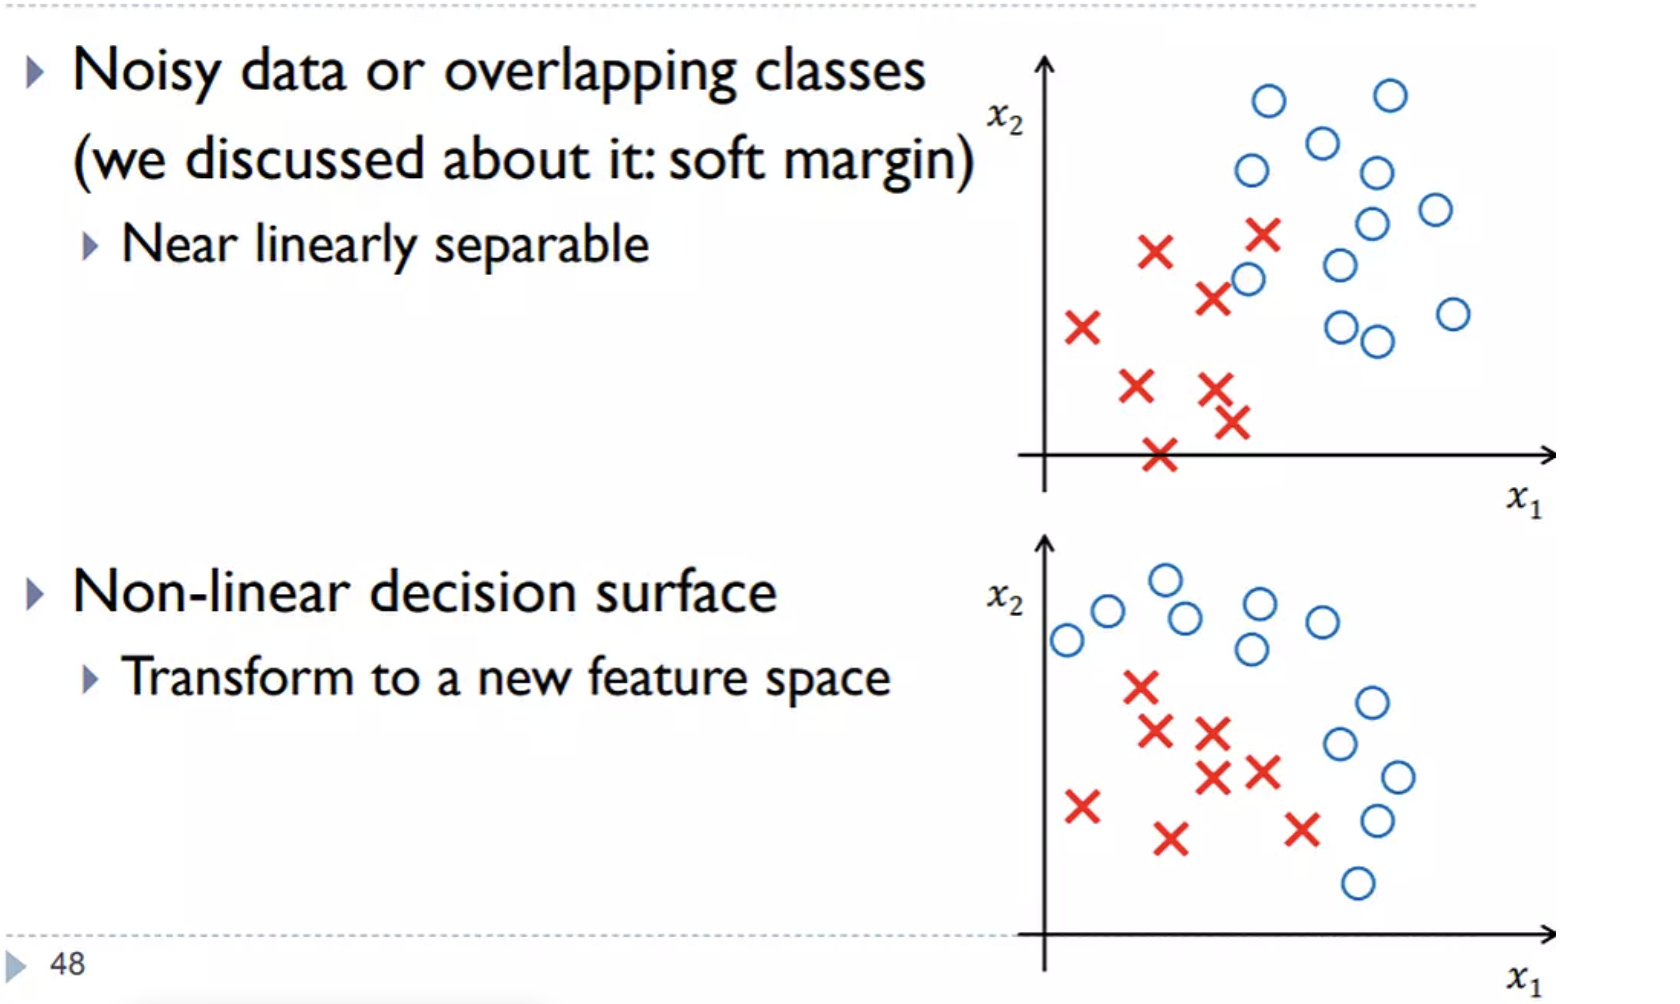
<center>Figure 14: different data distributions ,Adopted from [1]</center>
<br>

As seen in previous approaches for solving these kind of problems, we would take data into a new space and we would separate them using a linear line in that space.

Assume a transformation $\phi: R^d \rightarrow R^m$ on the feature space:
$$x \rightarrow \phi(x)$$
$$\phi(x) = [\phi_1(x), ..., \phi_m(x)] \\ \{\phi_1(x), ..., \phi_1(m)\} \text{ : set of basis functions (or features) } \\ \phi_i(x) = R^d \rightarrow R$$

And then we would find a hyperplane in the transformed feature space:

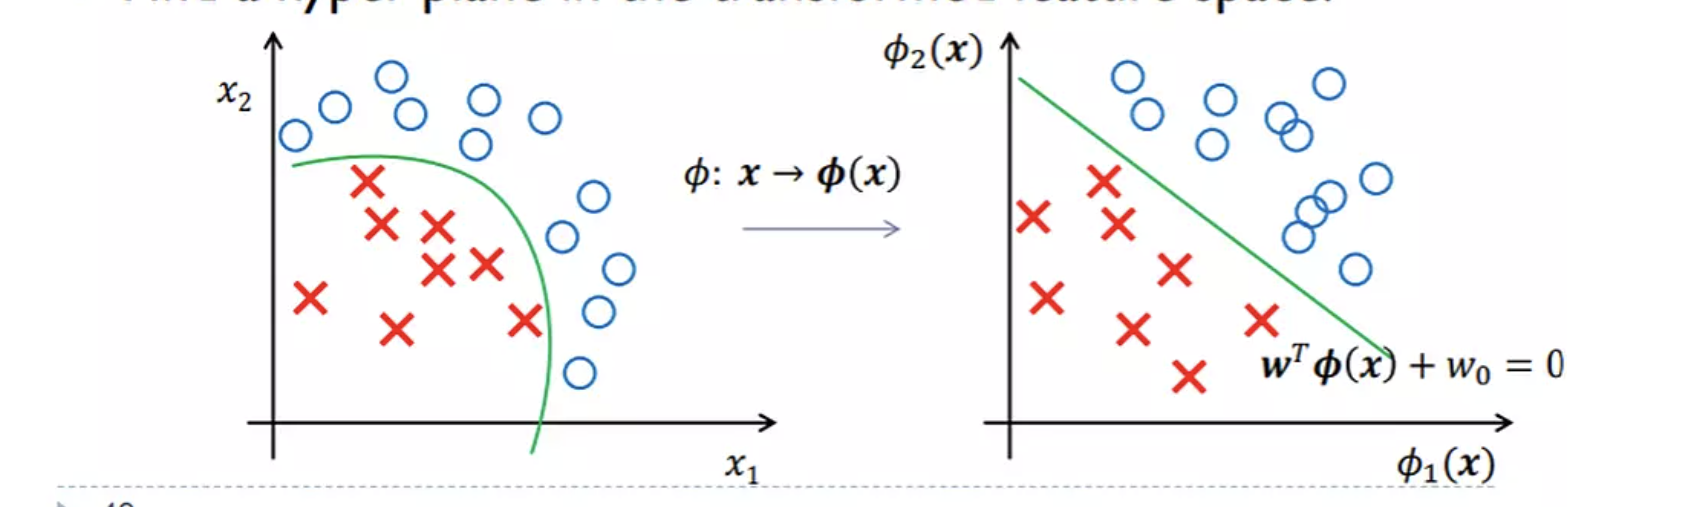
<center>Figure 15: hyperplane in a transformed feature space, Adopted from [1]</center>
<br>

The question is why don't we use primal and main of SVM and we'd better use the dual form of it?<br>
Look at the primal form of SVM when we took our data in a new space $\phi(x)$:

$$\min_{w, w_0} \frac{1}{2} ||w||^2 + C \sum_{n=1}^{N} \xi_n$$
$$\text{s.t. } y^{(n)}(w^T \phi(x^{(n)}) + w_0) \geq 1 - \xi_n \;\;\; n = 1, ..., N \\ \xi_n \geq 0$$

When we take $x$ to another dimension space $\phi$ the dimension of parameters $w$ should change based on that too so they be able to get inner mulitply together, And the number of parameters increase with the increase of the space's dimensionality. So we use dual form of the problem:

$$\max_{a}\{\sum_{n=1}^{N} \alpha_n - \frac{1}{2} \sum_{n=1}^{N}\sum_{m=1}^{N} \alpha_n \alpha_m y^{(n)}y^{(m)} \phi(x^{(n)})^T \phi(x^{(m)})\} \\ \text{ subject to } \;\;\;\; \sum_{n=1}^{N} \alpha_n y^{(n)} = 0 \\ 0 \leq \alpha_n \leq C \;\;\;\; n = 1, ..., N$$

In above we can see the dual form of the equation and as you can see we have an inner product of samples in their new space: 
$$\phi(x^{(n)})^T \phi(x^{(m)})$$

The equation above result in a number and there is no need for any parameter to change and all the parameters in the equation above stay the same ($\alpha_n, \alpha_m$).

So we have solved the parameter change problem with the dual form. Now the thing that might bother us later is that the $\phi$'s dimension's be very bit (like 1000) which can lead to increase in load of calculations and takes so much time for the inner product term for high dimensional mappings.

After we have calculated the vector W, what will our boundary look like? The first formula is showing the boundary. We already know what the vector W looks like. We can also calculate the value of $W_0$ with the help of a support vector.

$$\hat{y} = sign(w_0 + w^T\phi(x))$$
$$\text{where } w = \sum_{\alpha_n > 0} \alpha_n y^{(n)} \phi(x^{(n)})$$
$$w_0 = y^{(s)} - w^T\phi(x^{(s)})$$
$$(x^{(s)}, y^{(s)}): \text{ is a Support Vector data point}$$

> Now if we place $w, w_0$ in the boundary's equation we see that the inner product term appears.

Actually we don't want the data in the new space, their inner product would be enough. Now is there a way instead of calculating the data itself in the new space, just calculate theri inner product? That's the kernel's Idea.


### Kernel SVM:

Learns linear decision boundary in a high dimension space without explicitly working on the mapped data. It means that it does all the inner products without taking data samples to the new space $\phi$.<br>

Let $\phi(x)^T\phi(x') = K(x, x')$ (kernel)

> Now suppose we have a two-dimensional space and the value $\phi$ is defined as follows. Here we have calculated $\phi$ ourselves and have not used the method we mentioned.
<br>

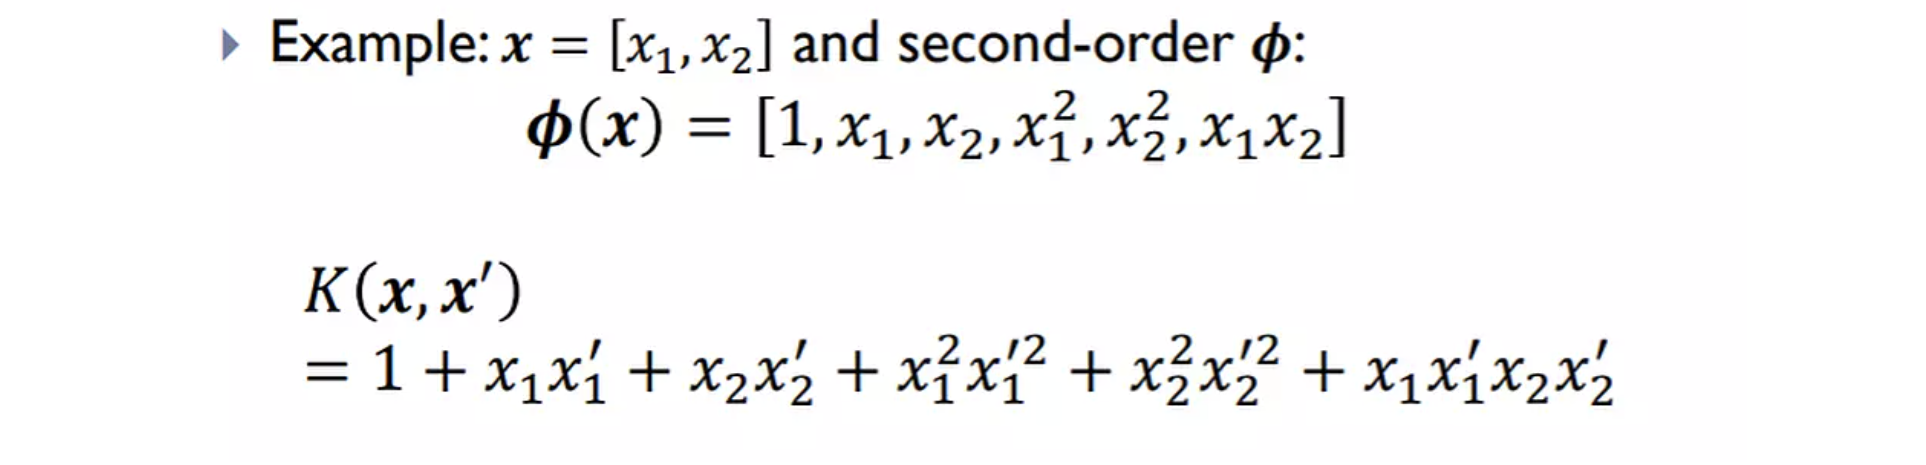

<br>

Now we want to solve the example above without taking data to the new space

Computing $K(x, x')$ without transforming $x$ and $x'$.<br>
Assume that we have defined kernel function as squared of 1 plus the inner product of the points in the original space.<br>
$$K = (1 + x^Tx')^2 = (1 + x_1x_1' + x_2x_2')^2 \\ = 1 + 2 x_1 x_1' + 2 x_2 x_2' + x_1^{2} x_1'^{2} + x_2^{2} x_2'^{2} + 2 x_1 x_1' x_2 x_2'$$
This is an inner product in:
$$\phi(x) = [1, \sqrt{2} x_1, \sqrt{2} x_2, x_1^2, x_2^2, \sqrt{2} x_1 x_2]$$
$$\phi(x) = [1, \sqrt{2} x_1', \sqrt{2} x_2', x_1'^2, x_2'^2, \sqrt{2} x_1' x_2']$$

> We see that the answer is exactly the same as before, except that the coefficient 2 appears in a series of expressions. Now, if we want to convert this inner product answer into two sets of points, the radical value of 2 appears in a series of expressions that cover the same value of 2 in the answer. Are the radical values of 2 important to us? No, thye are not important, we can ignore them.


Now let's see what happens for a $d$ dimensional problem.

**Plynomial Kernel**:

We saw that if we wanted to take our data samples to a degree two space, instead of taking all the data samples to the space and then calculate the inner product then, we use kernel tricks for such matter and do not need to take data samples to the new space:

We istead use $K(x, x') = (x^Tx' + 1)^2$ that corresponds to:
$$\text{d-dimensional feature space } x = [x_1, ..., x_d]^T$$
$$\phi(x) = [1, \sqrt{2} x_1, ..., \sqrt{2} x_d, x_1^2, ..., x_d^2, \sqrt{2} x_1x_2, ..., \sqrt{2} x_1x_d, \sqrt{2} x_2 x_3, ..., \sqrt{2} x_{d-1}x_d]^T$$


Now consider the above equation, for calculating the kernel between two data points our computations are in order of $d$. If we consider the order of power's 1, our summation would be $d$.


This can similarly be generalized to d-dimension $x$ and $\phi$s are polynomials of order *M*:
$$K(x, x') = (1 + x^Tx')^M = (1 + x_1x_1' + x_2x_2' + ... + x_dx_d')^M$$

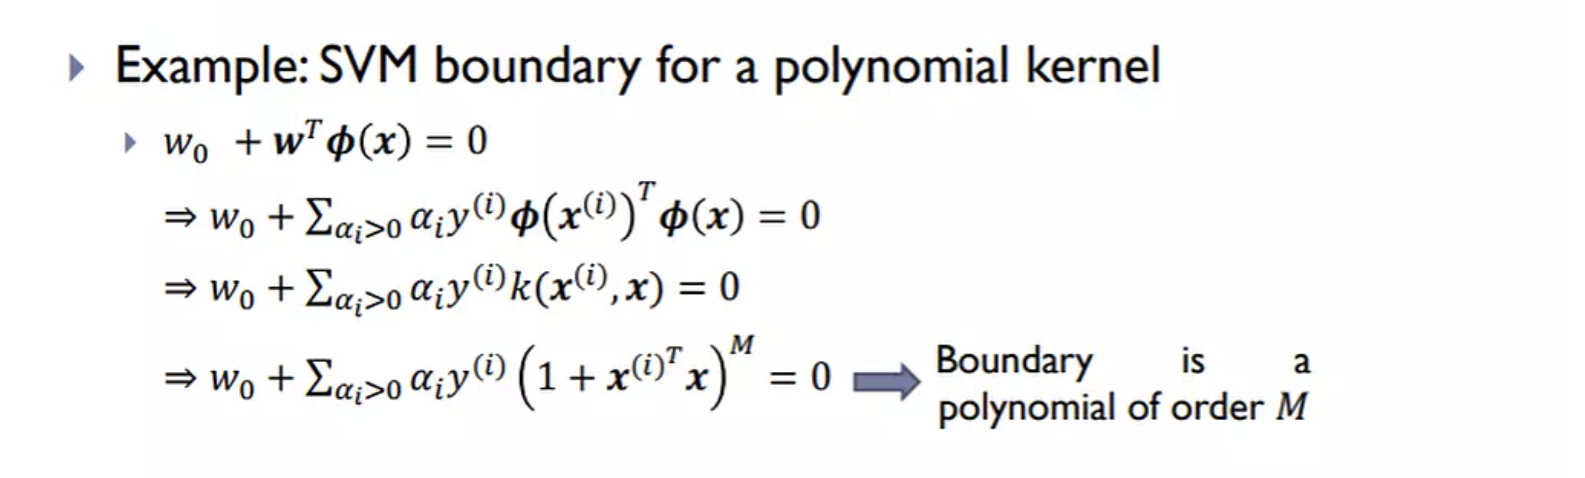
<br>


**Why use kernel trick**:

Now consider the case where our data is of dimension *d* and the kernel order is *2*. If we use the method of transforming the data to a new space and then multiplying them together internally, the order of the caculations is this case will be *d* to the power of 2, which is *m*. If we use the kernel, the complexity will be of order *d*.

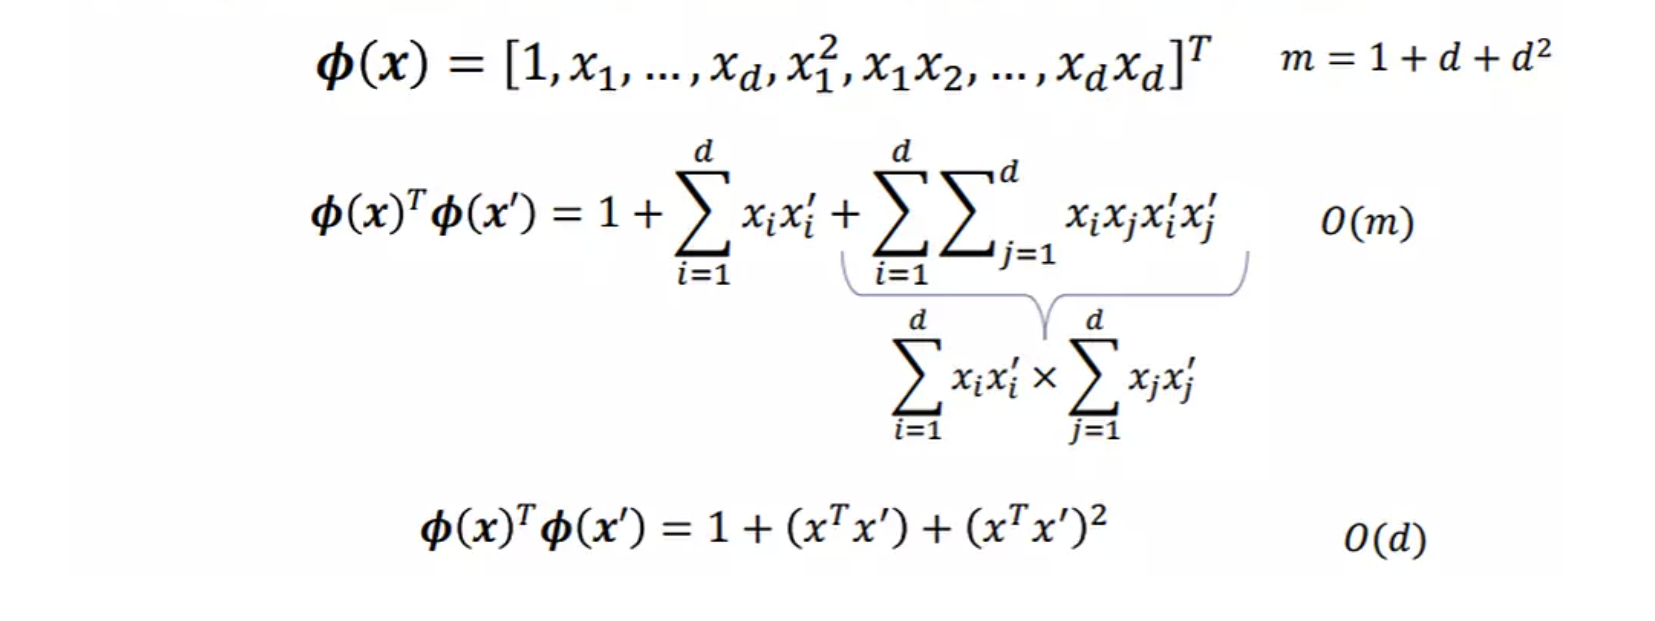
<br>

What we have analyzing here was polynomial kernel. We introduce a new kernel which is for when we increase the order of the new space to infinity and then we wanna do the inner multiplication there.

### Guassian Kernel or RBF

If $K(x, x')$ is an inner product in some transformed space of $x$, it is good.

What it is telling us is if we have two data points, I will calculate the power 2 of euclidean distance between them and divide them by $\gamma$ and place it in the below equation:

$$K(x, x') = \exp{(- \frac{||x - x'^2||^2}{\gamma})}$$

take one dimensional case with $\gamma = 1$ and one dimensional vectors:
We wanna see that to what-dimension space if we take our data is equivalent to use this type of kernel (What space does this inner product kernel of ponts take?):

$$K(x, x') = \exp{(-(x - x')^2)}$$
$$= \exp{(-x^2)} \exp{(-x'^2)} \exp{(2xx')}$$
$$ = \exp{(-x^2)} \exp{(-x'^2)} \sum_{k=1}^{\infty} \frac{2^kx^kx'^k}{k!}$$

As we knew we had the form below:

$$K(x, x') = \phi(x) \phi(x')$$

If we want to determine the transformation $\phi$ that leads to the kernel equation above, the same transformation must be applied to both $x$ and $x'$, and then their inner product gives us the kernel value.

We see that everything is fine we have both $\exp{(-x^2)} \exp{(-x'^2)}$, but the problem is with $\exp{(2xx')}$, wahat should we do with it?<br>

To solve it's problem we write the taylor expansion of  $\exp{(2xx')}$ and it result in the expansion below:

$$\sum_{k = 1}^{\infty} \frac{2^kx^kx'^k}{k!}$$

And we see that expressions are based on $x^k, x'^k$.
Now what we saw above was the inner product of $\phi(x)$ and $\phi(x')$, Now what is the equation for $\phi(x)$:

$$\phi(x) = \exp{(-x^2)} [x^0\times \sqrt{\frac{2^0}{0!}}, x^1\times \sqrt{\frac{2^1}{1!}}, ...]$$

> It kind of looks like we're taking data to the infiite-dimension space.

### Some Common kenrel functions:
+ Linear: $K(x, x') = x^Tx'$
+ Polynomial: $K(x, x') = (x^Tx' + 1)^M$
+ Guassian: $K(x, x') = \exp{-(\frac{||x - x'||^2}{\gamma})}$
+ Sigmoid: $K(x, x') = \tanh{(\alpha x^Tx' + b)}$

---
`There are more to kernel discussion but we leave it for later for now.`

---


### Referrences:

[1] [SVM slides, ML course, Mahdye Soleymani, SU](https://virgool.io/@haniehmahdavi26/%D8%AC%D8%B2%D9%88%D9%87-%D8%AF%D9%88%D8%B1%D9%87-%DB%8C%D8%A7%D8%AF%DA%AF%DB%8C%D8%B1%DB%8C-%D9%85%D8%A7%D8%B4%DB%8C%D9%86-%D8%AF%DA%A9%D8%AA%D8%B1-%D9%85%D9%87%D8%AF%DB%8C%D9%87-%D8%B3%D9%84%DB%8C%D9%85%D8%A7%D9%86%DB%8C-%D8%AC%D9%84%D8%B3%D9%87-%D8%AF%D9%87%D9%85-%D8%AF%D8%B3%D8%AA%D9%87-%D8%A8%D9%86%D8%AF-svm-hjzuuodq4sps)<br>
[2] [Stochastic Regression, ML course, Mahdye Soleymani, SU](https://virgool.io/@haniehmahdavi26/%D8%AC%D8%B2%D9%88%D9%87-%D8%AF%D9%88%D8%B1%D9%87-%DB%8C%D8%A7%D8%AF%DA%AF%DB%8C%D8%B1%DB%8C-%D9%85%D8%A7%D8%B4%DB%8C%D9%86-%D8%AF%DA%A9%D8%AA%D8%B1-%D9%85%D9%87%D8%AF%DB%8C%D9%87-%D8%B3%D9%84%DB%8C%D9%85%D8%A7%D9%86%DB%8C-%D8%AC%D9%84%D8%B3%D9%87-%D8%B4%D8%B4%D9%85-%D8%B1%DA%AF%D8%B1%D8%B3%DB%8C%D9%88%D9%86-%D8%A8%D8%A7-%D8%AF%DB%8C%D8%AF%DA%AF%D8%A7%D9%87-%D8%A7%D8%AD%D8%AA%D9%85%D8%A7%D9%84%D8%A7%D8%AA%DB%8C-%DA%A9%D9%84%D8%B3%DB%8C%D9%81%DB%8C%DA%A9%DB%8C%D8%B4%D9%86-qzumirzraaxn)<br>
[3] []()<br>
[4] []()<br>
[5] []()<br>
[6] []()<br>
[7] []()<br>